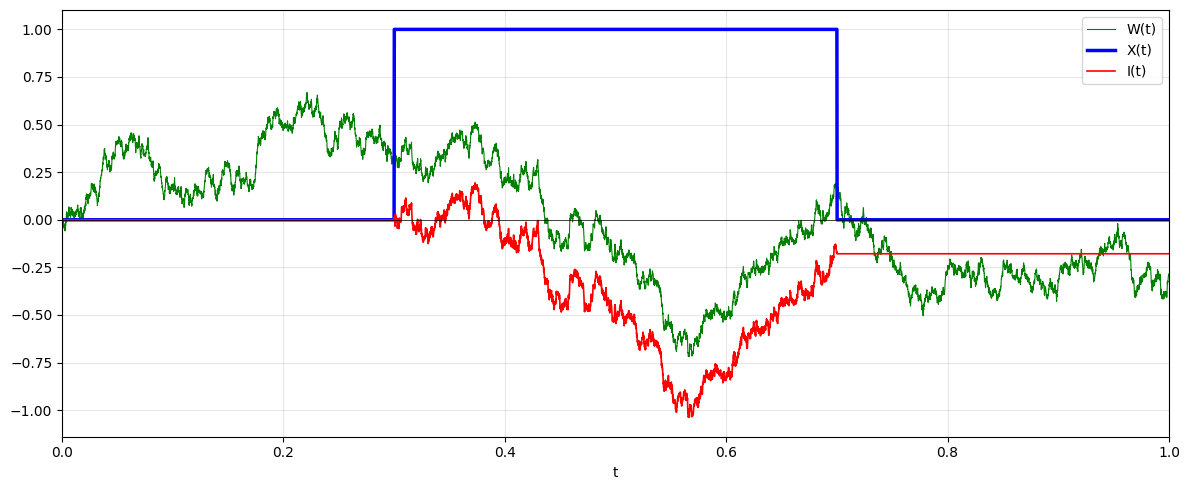

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10000                 # number of grid points (including 0 and T)
T = 1.0
a, b = 0.3, 0.7
C = 1#np.random.normal(0, 1)  # constant for X_t = C * 1_(a,b](t)

# Time grid and Brownian motion
t = np.linspace(0, T, N)
dt = T / (N - 1)

dW = np.random.normal(0, np.sqrt(dt), N - 1)
W = np.concatenate(([0.0], np.cumsum(dW)))  # W(0)=0, same length as t

# X(t) = C * 1_(a,b](t)
X = np.where((t > a) & (t <= b), C, 0.0)

# Indices for a and b
idx_a = np.searchsorted(t, a, side='right') - 1
idx_b = np.searchsorted(t, b, side='right') - 1

# Correct stopped processes:
# t∧a = t for t<=a, and a for t>a
# t∧b = t for t<=b, and b for t>b
W_t_and_a = np.where(np.arange(N) <= idx_a, W, W[idx_a])
W_t_and_b = np.where(np.arange(N) <= idx_b, W, W[idx_b])

# Stochastic integral I(t) = C * (W_{t∧b} - W_{t∧a})
I = C * (W_t_and_b - W_t_and_a)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, W, color='green', lw=0.8, label='W(t)')
ax.plot(t, X, color='blue', lw=2.5, label='X(t)')
ax.plot(t, I, color='red', lw=1.2, label='I(t)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlim(0, 1)
ax.set_xlabel('t')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()